## 사용자 맞춤형 패션 스타일 추천 시스템
본 노트북은 샘플 데이터(28,465행)를 바탕으로 사용자의 개인적 특성과 취향을 분석하여 최적의 패션 스타일을 제안하는 로직을 담고 있습니다.

1. 주요 기능
- 입력 데이터: 성별, 퍼스널 컬러, 설문 질문별 답변
- 분석 로직: 사용자 입력값과 데이터셋 간의 유사도/매칭 점수 계산
- 출력 결과: 추천 스타일 Top 3 (형식: 이미지 파일명/스타일/시대)

2. 향후 확장 계획
- 추천된 스타일 결과를 바탕으로 무신사(Musinsa) 및 지그재그(Zigzag) 딥링크 연동
- 필터링 및 검색 자동화를 통해 실질적인 상품 구매 페이지로 연결

In [53]:
# 2. 구글 드라이브 연동 (대용량 파일 추천)
# 구글 드라이브에 Sample.zip을 업로드하신 후 아래 코드를 실행하세요.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
# 연동 후, 드라이브에 있는 압축 파일을 복사해오거나 바로 압축 해제할 수 있습니다.
# 경로에 공백이 있으므로 따옴표로 묶어줍니다. (이미 해제되었으므로 주석 처리)
# !unzip "/content/drive/MyDrive/맵시TI/=================== 맵시TI ===================/Sample.zip" -d /content/sample_data/fashion_data

In [55]:
import os

data_dir = '/content/sample_data/fashion_data'
files = os.listdir(data_dir)
print(f"전체 파일 개수: {len(files)}")
print("파일 목록 샘플:", files[:10]) # 처음 10개만 출력

전체 파일 개수: 1
파일 목록 샘플: ['Sample']


In [56]:
import json
import pandas as pd
from tqdm.notebook import tqdm  # 진행률 표시 바

def integrate_fashion_data(base_path):
    all_rows = []

    # 모든 하위 폴더 순회
    json_files = []
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith('.json'):
                json_files.append(os.path.join(root, file))

    print(f"총 {len(json_files)}개의 JSON 파일을 찾았습니다. 통합을 시작합니다.")

    # 각 파일을 읽어서 Flatten 후 리스트에 담기
    for file_path in tqdm(json_files, desc="데이터 통합 중"):
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                content = json.load(f)

                # json_normalize로 item, user 등을 한 줄로 펴기
                flat_data = pd.json_normalize(content)
                all_rows.append(flat_data)
        except Exception as e:
            print(f"오류 발생 파일 ({os.path.basename(file_path)}): {e}")

    # 모든 데이터프레임을 하나로 합치기
    if all_rows:
        combined_df = pd.concat(all_rows, ignore_index=True)
        return combined_df
    else:
        return None

# 실행
base_path = '/content/sample_data/fashion_data'
df = integrate_fashion_data(base_path)

# 결과 확인
if df is not None:
    print(f"\n✅ 통합 완료! 총 {len(df)}행의 데이터가 준비되었습니다.")
    display(df.head())
else:
    print("❌ 데이터를 찾지 못했습니다. 경로를 확인해주세요.")

총 28465개의 JSON 파일을 찾았습니다. 통합을 시작합니다.


데이터 통합 중:   0%|          | 0/28465 [00:00<?, ?it/s]


✅ 통합 완료! 총 28465행의 데이터가 준비되었습니다.


,E_id,imgName,item.imgName,item.era,item.style,item.gender,item.survey.Q1,item.survey.Q2,item.survey.Q3,item.survey.Q411,...,user.r_gender,user.age,user.mar,user.job,user.income,user.r_style1,user.r_style2,user.r_style3,user.r_style4,user.r_style5
0,235836,T_21459_70_hippie_W.jpg,T_21459_70_hippie_W.jpg,1970,hippie,W,3,1,2,2,...,2,2,2,4,3,2,2,2,2,1
1,29825,T_16832_70_hippie_W.jpg,T_16832_70_hippie_W.jpg,1970,hippie,W,3,1,2,1,...,2,3,1,4,2,2,1,2,2,2
2,247950,T_21158_70_disco_W.jpg,T_21158_70_disco_W.jpg,1970,disco,W,2,3,4,3,...,2,3,2,4,1,2,2,2,2,2
3,235822,T_21464_70_punk_W.jpg,T_21464_70_punk_W.jpg,1970,punk,W,1,1,4,2,...,2,2,2,4,3,2,2,2,2,1
4,99528,T_21100_70_hippie_W.jpg,T_21100_70_hippie_W.jpg,1970,hippie,W,1,1,2,1,...,2,4,2,1,5,2,2,1,2,1


In [57]:
print("전체 컬럼 개수:", len(df.columns))

# 추천 로직에 사용할 주요 컬럼들만 필터링
key_columns = [col for col in df.columns if 'Q42' in col or 'gender' in col]
print("확인된 주요 컬럼 샘플:", key_columns[:10])


전체 컬럼 개수: 41
확인된 주요 컬럼 샘플: ['item.gender', 'item.survey.Q4201', 'item.survey.Q4202', 'item.survey.Q4203', 'item.survey.Q4204', 'item.survey.Q4205', 'item.survey.Q4206', 'item.survey.Q4207', 'item.survey.Q4208', 'item.survey.Q4209']


In [58]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

def recommend_fashion(user_input, df, fit_weight=1.5):
    # --------------------------------------------------------
    # [Step 1] Hard Filtering (Style & Basics)
    # --------------------------------------------------------
    # 1. 성별 필터링
    sub_df = df[df['item.gender'] == user_input['user_gender']].copy()

    # 2. 연령 필터링 제거 (사용자 요청)
    # age_col 필터 로직 삭제

    # 3. 스타일 키워드 필터링 (최종 선택한 스타일)
    target_style = user_input.get('target_style', '')
    if target_style and 'item.style' in sub_df.columns:
        sub_df = sub_df[sub_df['item.style'].str.contains(target_style, case=False, na=False)]

    if sub_df.empty:
        print(f"경고: 조건(성별/스타일 '{target_style}')에 맞는 아이템이 없습니다.")
        return []

    # --------------------------------------------------------
    # [Step 2] User Preference Vector Generation
    # --------------------------------------------------------
    user_answers = user_input['user_answers']

    # 벡터에 사용할 피처 컬럼: Q411(핏) + Q4201~Q4216(이미지 특징)
    q42_cols = [f'item.survey.Q42{str(i).zfill(2)}' for i in range(1, 17)]
    feature_columns = ['item.survey.Q411'] + q42_cols

    # 데이터셋에 누락된 컬럼 0.0으로 초기화
    for col in feature_columns:
        if col not in sub_df.columns:
            sub_df[col] = 0.0

    # 사용자 벡터 초기화
    user_vector_dict = {col: 0.0 for col in feature_columns}

    # --- 핏(Fit) 가중치 설정 (Q1) ---
    q1_answer = user_answers[0] if len(user_answers) > 0 else 'B'
    if q1_answer == 'A':   # 타이트한 핏
        fit_target = 0.1
    elif q1_answer == 'B': # 레귤러 핏
        fit_target = 0.5
    elif q1_answer == 'C': # 루즈/오버핏
        fit_target = 0.9
    else:
        fit_target = 0.5

    user_vector_dict['item.survey.Q411'] = fit_target

    # --- 무드 가중치 설정 ---
    mood_answer = user_answers[1] if len(user_answers) > 1 else ''
    if mood_answer == 'A-1':
        user_vector_dict['item.survey.Q4201'] = 2.0
        user_vector_dict['item.survey.Q4202'] = 2.0
    elif mood_answer == 'B-2':
        user_vector_dict['item.survey.Q4205'] = 2.0
        user_vector_dict['item.survey.Q4206'] = 2.0
    elif mood_answer == 'C-3':
        user_vector_dict['item.survey.Q4215'] = 2.0
        user_vector_dict['item.survey.Q4216'] = 2.0

    # 매트릭스 변환 및 가중치 적용
    item_matrix = sub_df[feature_columns].fillna(0).astype(float).values
    user_vector = pd.Series(user_vector_dict)[feature_columns].values.reshape(1, -1)

    item_matrix[:, 0] *= fit_weight
    user_vector[:, 0] *= fit_weight

    # 스케일링
    scaler = MinMaxScaler()
    scaled_item_matrix = scaler.fit_transform(item_matrix)
    scaled_user_vector = scaler.transform(user_vector)

    # 코사인 유사도 계산
    similarities = cosine_similarity(scaled_user_vector, scaled_item_matrix)[0]
    sub_df['similarity_score'] = similarities

    # --------------------------------------------------------
    # [Step 3] Result Output (안내 메시지 포함)
    # --------------------------------------------------------
    top_recommendations = sub_df.sort_values(by='similarity_score', ascending=False).head(3)

    results = []
    for _, row in top_recommendations.iterrows():
        item_fit_val = float(row.get('item.survey.Q411', 0.5))
        notice = ""
        if q1_answer == 'A' and item_fit_val > 0.6:
            notice = "(이 아이템은 귀하가 선호하는 스타일이지만 약간 더 넉넉한 핏입니다)"
        elif q1_answer == 'C' and item_fit_val < 0.4:
            notice = "(이 아이템은 귀하가 선호하는 스타일이지만 약간 더 타이트한 핏입니다)"

        results.append({
            'imgName': row['imgName'],
            'style': row['item.style'],
            'era': row.get('item.era', 'Unknown'),
            'score': row['similarity_score'],
            'notice': notice
        })

    return results

print("✅ 연령 필터 제거 및 추천 로직 업데이트 완료!")

✅ 연령 필터 제거 및 추천 로직 업데이트 완료!


In [59]:
# 연령 정보가 제거된 테스트 입력
user_input_example = {
    'user_gender': 'W',
    'user_pc': '겨울 딥',
    'user_answers': ['C', 'C-3', 'A', 'B'], # 1번: 핏(C: 루즈핏), 2번: 무드(C-3)
    'target_style': 'hippie'
}

# 추천 수행
recommendations = recommend_fashion(user_input_example, df, fit_weight=1.5)

print(f"\n[연령 필터 제거 후] Top 3 패션 추천 (타겟: {user_input_example['target_style']}):")
if recommendations:
    for i, rec in enumerate(recommendations, 1):
        notice_text = f"\n    => 💡 {rec['notice']}" if rec['notice'] else ""
        print(f"[{i}위] Img: {rec['imgName']} | Style: {rec['style']} | Score: {rec['score']:.3f}{notice_text}")
else:
    print("조건에 맞는 추천 결과가 여전히 없습니다. 스타일 키워드를 확인해주세요.")


[연령 필터 제거 후] Top 3 패션 추천 (타겟: hippie):
[1위] Img: T_21926_70_hippie_W.jpg | Style: hippie | Score: 0.704
[2위] Img: T_20662_70_hippie_W.jpg | Style: hippie | Score: 0.537
[3위] Img: T_20669_70_hippie_W.jpg | Style: hippie | Score: 0.537


In [60]:
import json
from typing import Dict, List, Optional, Any
from dataclasses import dataclass

# ==========================================
# [1] 매핑 테이블 (확장성 고려)
# ==========================================

WARM_COLOR_MAP = {
    "A": "spring_light",
    "B": "spring_bright",
    "C": "autumn_muted",
    "D": "autumn_deep"
}

COOL_COLOR_MAP = {
    "A": "summer_light",
    "B": "summer_muted",
    "C": "winter_bright",
    "D": "winter_deep"
}

VALID_PERSONAL_COLORS = set(WARM_COLOR_MAP.values()) | set(COOL_COLOR_MAP.values()) | {
    "spring_warm", "summer_cool", "autumn_warm", "winter_cool", "unknown"
}

STYLE_CATEGORIES = [
    "sophisticated", "modern_minimal", "feminine", "mannish", "casual",
    "romantic", "street", "sporty", "hipster_punk", "retro"
]

# qstyle_2는 핏(Fit) 질문이므로 스타일 범주에서 제외
STYLE_SCORE_MAP = {
    "qstyle_1": {
        "A": ["sophisticated", "modern_minimal", "feminine", "mannish"],
        "B": ["casual", "romantic", "street", "sporty", "hipster_punk", "retro"]
    },
    "qstyle_3": {
        "A": ["feminine", "sophisticated", "hipster_punk", "romantic"],
        "B": ["casual", "street", "sporty", "mannish", "retro"]
    },
    "qstyle_4": {
        "A": ["modern_minimal", "casual", "mannish", "sophisticated"],
        "B": ["hipster_punk", "retro", "street", "romantic"]
    },
    "qstyle_5": {
        "A": ["romantic", "feminine", "sophisticated", "modern_minimal", "retro"],
        "B": ["sporty", "casual", "street", "hipster_punk", "mannish"]
    },
    "qstyle_6": {
        "A": ["mannish", "modern_minimal", "sophisticated", "street"],
        "B": ["romantic", "retro", "feminine", "casual"]
    }
}

# ==========================================
# [2] 데이터 구조 및 검증 (Data Validation)
# ==========================================

@dataclass
class UserInput:
    gender: str
    personal_color_input: str
    warmcool_q1: Optional[str] = None
    warmcool_q2: Optional[str] = None
    warmcool_q3: Optional[str] = None
    qwarm: Optional[str] = None
    qcool: Optional[str] = None
    qstyle_1: Optional[str] = None
    qstyle_2: Optional[str] = None
    qstyle_3: Optional[str] = None
    qstyle_4: Optional[str] = None
    qstyle_5: Optional[str] = None
    qstyle_6: Optional[str] = None

    def __post_init__(self):
        if self.gender not in ["M", "W"]:
            raise ValueError("Gender must be 'M' or 'W'.")
        if self.personal_color_input not in VALID_PERSONAL_COLORS:
            raise ValueError(f"Invalid personal_color_input: {self.personal_color_input}")

# ==========================================
# [3] 핵심 비즈니스 로직 클래스
# ==========================================

class RecommendationEngine:
    def __init__(self, raw_input: Dict[str, Any]):
        self.user_data = UserInput(**raw_input)

    def determine_personal_color(self) -> Dict[str, Any]:
        """퍼스널 컬러 결정 로직"""
        if self.user_data.personal_color_input != "unknown":
            return {
                "personal_color": self.user_data.personal_color_input,
                "personal_color_source": "direct",
                "personal_color_confidence": 1.0,
                "warmcool_path": None
            }

        # Inferred logic
        answers = [
            self.user_data.warmcool_q1,
            self.user_data.warmcool_q2,
            self.user_data.warmcool_q3
        ]
        warm_count = answers.count("A")
        cool_count = answers.count("B")

        path_info = {
            "warm_count": warm_count,
            "cool_count": cool_count,
            "branch": None,
            "detail_answer": None
        }

        if warm_count > cool_count:
            path_info["branch"] = "warm"
            detail = self.user_data.qwarm
            path_info["detail_answer"] = detail
            color = WARM_COLOR_MAP.get(detail, "unknown_warm")
            return {
                "personal_color": color,
                "personal_color_source": "inferred",
                "personal_color_confidence": 0.9,
                "warmcool_path": path_info
            }
        elif cool_count > warm_count:
            path_info["branch"] = "cool"
            detail = self.user_data.qcool
            path_info["detail_answer"] = detail
            color = COOL_COLOR_MAP.get(detail, "unknown_cool")
            return {
                "personal_color": color,
                "personal_color_source": "inferred",
                "personal_color_confidence": 0.9,
                "warmcool_path": path_info
            }
        else:
            # Tie condition
            path_info["branch"] = "tie"
            return {
                "personal_color": "needs_more_info",
                "personal_color_source": "inferred",
                "personal_color_confidence": 0.3,
                "warmcool_path": path_info
            }

    def calculate_styles_and_fit(self) -> Dict[str, Any]:
        """스타일 점수 누적 및 핏 계산 로직"""
        style_scores = {style: 0 for style in STYLE_CATEGORIES}
        fit_scores = {"tight_normal": 0, "loose": 0}

        # 스타일 질문 처리
        for q_key, q_map in STYLE_SCORE_MAP.items():
            user_ans = getattr(self.user_data, q_key)
            if user_ans in q_map:
                for style in q_map[user_ans]:
                    style_scores[style] += 1

        # 핏 질문 처리 (Qstyle_2)
        if self.user_data.qstyle_2 == "A":
            fit_scores["tight_normal"] += 1
        elif self.user_data.qstyle_2 == "B":
            fit_scores["loose"] += 1

        # Primary / Secondary 분류
        sorted_styles = sorted(style_scores.items(), key=lambda x: x[1], reverse=True)
        max_score = sorted_styles[0][1]
        primary_style = sorted_styles[0][0]

        secondary_styles = [
            style for style, score in sorted_styles[1:]
            if max_score - score <= 1 and score > 0
        ]

        # Fit 결정
        if fit_scores["tight_normal"] > fit_scores["loose"]:
            rec_fit = "tight_or_normal"
        elif fit_scores["loose"] > fit_scores["tight_normal"]:
            rec_fit = "loose_or_overfit"
        else:
            rec_fit = "balanced"

        return {
            "style_scores": style_scores,
            "primary_style": primary_style,
            "secondary_styles": secondary_styles,
            "fit_scores": fit_scores,
            "recommended_fit": rec_fit
        }

    def generate_recommendation(self) -> Dict[str, Any]:
        """최종 결과 반환"""
        pc_info = self.determine_personal_color()
        style_info = self.calculate_styles_and_fit()

        return {
            "gender": self.user_data.gender,
            **pc_info,
            **style_info
        }

# ==========================================
# [4] 실행 및 테스트
# ==========================================

def run_test(test_name: str, input_data: Dict[str, Any]):
    print(f"\n--- {test_name} ---")
    try:
        engine = RecommendationEngine(input_data)
        result = engine.generate_recommendation()
        print(json.dumps(result, indent=2, ensure_ascii=False))
    except Exception as e:
        print(f"Error: {e}")



--- Test Case 1: Direct PC & B-heavy Style ---
{
  "gender": "W",
  "personal_color": "summer_muted",
  "personal_color_source": "direct",
  "personal_color_confidence": 1.0,
  "warmcool_path": null,
  "style_scores": {
    "sophisticated": 1,
    "modern_minimal": 1,
    "feminine": 2,
    "mannish": 1,
    "casual": 3,
    "romantic": 4,
    "street": 3,
    "sporty": 2,
    "hipster_punk": 2,
    "retro": 5
  },
  "primary_style": "retro",
  "secondary_styles": [
    "romantic"
  ],
  "fit_scores": {
    "tight_normal": 0,
    "loose": 1
  },
  "recommended_fit": "loose_or_overfit"
}

--- Test Case 2: Inferred PC (Warm) & A-heavy Style ---
{
  "gender": "M",
  "personal_color": "spring_bright",
  "personal_color_source": "inferred",
  "personal_color_confidence": 0.9,
  "warmcool_path": {
    "warm_count": 2,
    "cool_count": 1,
    "branch": "warm",
    "detail_answer": "B"
  },
  "style_scores": {
    "sophisticated": 4,
    "modern_minimal": 3,
    "feminine": 2,
    "mannish":

In [61]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

# 1. 사용자 요청 스타일별 핵심 속성 매핑
STYLE_FEATURE_MAP = {
    "sophisticated": ["item.survey.Q4202", "item.survey.Q4204"],
    "feminine": ["item.survey.Q4214", "item.survey.Q4216"],
    "hipster_punk": ["item.survey.Q4209", "item.survey.Q4206", "item.survey.Q4207"],
    "casual": ["item.survey.Q4210", "item.survey.Q4212"],
    "modern_minimal": ["item.survey.Q4205", "item.survey.Q4208"],
    "romantic": ["item.survey.Q4213", "item.survey.Q4216"],
    "mannish": ["item.survey.Q4215", "item.survey.Q4202"],
    "street": ["item.survey.Q4207", "item.survey.Q4203"],
    "sporty": ["item.survey.Q4211", "item.survey.Q4212"],
    "retro": ["item.survey.Q4207", "item.survey.Q412"] # retro/vintage
}

def recommend_mapped_images(backend_json: dict, df: pd.DataFrame):
    target_gender = backend_json.get("gender", "W")
    primary_style = backend_json.get("primary_style", "")

    # 성별 필터링
    sub_df = df[df['item.gender'] == target_gender].copy()

    if primary_style not in STYLE_FEATURE_MAP:
        print(f"⚠️ '{primary_style}'에 대한 매핑 정보가 없습니다.")
        return []

    target_features = STYLE_FEATURE_MAP[primary_style]

    # 데이터셋에 누락된 컬럼 처리
    for col in target_features:
        if col not in sub_df.columns:
            sub_df[col] = 0.0

    # 핵심 변수들의 합산을 통해 매칭 점수 계산 (각 특성이 강하게 나타나는 아이템 선호)
    # Q412(명도) 등 척도가 다를 수 있으므로 MinMax 스케일링 적용
    feature_data = sub_df[target_features].fillna(0).astype(float)
    scaler = MinMaxScaler()
    scaled_features = scaler.fit_transform(feature_data)

    # 스케일링된 값들의 평균(또는 합)을 해당 아이템의 최종 '스타일 적합도' 점수로 사용
    sub_df['style_match_score'] = scaled_features.mean(axis=1)

    # 상위 3개 추출
    top_items = sub_df.sort_values(by='style_match_score', ascending=False).head(3)

    results = []
    for _, row in top_items.iterrows():
        results.append({
            'imgName': row['imgName'],
            'style': row.get('item.style', 'Unknown'),
            'score': row['style_match_score']
        })

    return results

# --- 실행 테스트 ---
# 이전 단계에서 도출된 backend_result와 실제 이미지가 존재하는 df_with_images 사용
print("[설문 분석 최종 스타일]")
print(f"- Primary Style: {backend_result['primary_style'].upper()}")
print(f"- 맵핑된 변수: {STYLE_FEATURE_MAP.get(backend_result['primary_style'], [])}\n")

print("[매핑 변수 기반 추천 이미지 파일 Top 3]")
mapped_image_results = recommend_mapped_images(backend_result, df_with_images)

if mapped_image_results:
    for i, res in enumerate(mapped_image_results, 1):
        print(f"{i}위 | 파일명: {res['imgName']} | 스타일: {res['style']} | 매칭 점수: {res['score']:.3f}")
else:
    print("조건에 맞는 추천 이미지가 없습니다.")

[설문 분석 최종 스타일]
- Primary Style: RETRO
- 맵핑된 변수: ['item.survey.Q4207', 'item.survey.Q412']

[매핑 변수 기반 추천 이미지 파일 Top 3]
1위 | 파일명: T_16780_70_hippie_W.jpg | 스타일: hippie | 매칭 점수: 1.000
2위 | 파일명: T_16786_70_disco_W.jpg | 스타일: disco | 매칭 점수: 1.000
3위 | 파일명: T_01064_00_ecology_W.jpg | 스타일: ecology | 매칭 점수: 1.000


In [69]:
# [테스트 케이스 1] 직접 선택 + 핏(loose) + 특정 스타일 답변
test_input_1 = {
    "gender": "M",
    "personal_color_input": "summer_muted",
    "qstyle_1": "B", "qstyle_2": "B", "qstyle_3": "B",
    "qstyle_4": "B", "qstyle_5": "A", "qstyle_6": "B"
}

# [테스트 케이스 2] 추론(unknown) + 웜톤(A가 많음) + 핏(tight) + 다른 스타일 답변
test_input_2 = {
    "gender": "M",
    "personal_color_input": "unknown",
    "warmcool_q1": "A", "warmcool_q2": "A", "warmcool_q3": "B",
    "qwarm": "B", "qcool": None,
    "qstyle_1": "A", "qstyle_2": "A", "qstyle_3": "A",
    "qstyle_4": "A", "qstyle_5": "B", "qstyle_6": "A"
}

run_test("Test Case 1: Direct PC & B-heavy Style", test_input_1)
run_test("Test Case 2: Inferred PC (Warm) & A-heavy Style", test_input_2)


--- Test Case 1: Direct PC & B-heavy Style ---
{
  "gender": "M",
  "personal_color": "summer_muted",
  "personal_color_source": "direct",
  "personal_color_confidence": 1.0,
  "warmcool_path": null,
  "style_scores": {
    "sophisticated": 1,
    "modern_minimal": 1,
    "feminine": 2,
    "mannish": 1,
    "casual": 3,
    "romantic": 4,
    "street": 3,
    "sporty": 2,
    "hipster_punk": 2,
    "retro": 5
  },
  "primary_style": "retro",
  "secondary_styles": [
    "romantic"
  ],
  "fit_scores": {
    "tight_normal": 0,
    "loose": 1
  },
  "recommended_fit": "loose_or_overfit"
}

--- Test Case 2: Inferred PC (Warm) & A-heavy Style ---
{
  "gender": "M",
  "personal_color": "spring_bright",
  "personal_color_source": "inferred",
  "personal_color_confidence": 0.9,
  "warmcool_path": {
    "warm_count": 2,
    "cool_count": 1,
    "branch": "warm",
    "detail_answer": "B"
  },
  "style_scores": {
    "sophisticated": 4,
    "modern_minimal": 3,
    "feminine": 2,
    "mannish":

🌟 [테스트 케이스 1 실행 결과] 🌟
🛍️ [STEP 1] 무신사 / 지그재그 딥링크 연동용 메타데이터 출력
▶ 검색 키워드(스타일)     : RETRO
▶ 검색 키워드(퍼스널컬러) : summer_muted
▶ 검색 키워드(핏)         : loose_or_overfit

💡 향후 이 키워드들을 조합하여 쇼핑몰 검색 URL(딥링크)을 자동 생성할 수 있습니다.
   (예시: https://www.musinsa.com/search/musinsa/integration?q=RETRO+summer_muted)

📸 [STEP 2] 자체 데이터셋 기반 스타일 레퍼런스 이미지


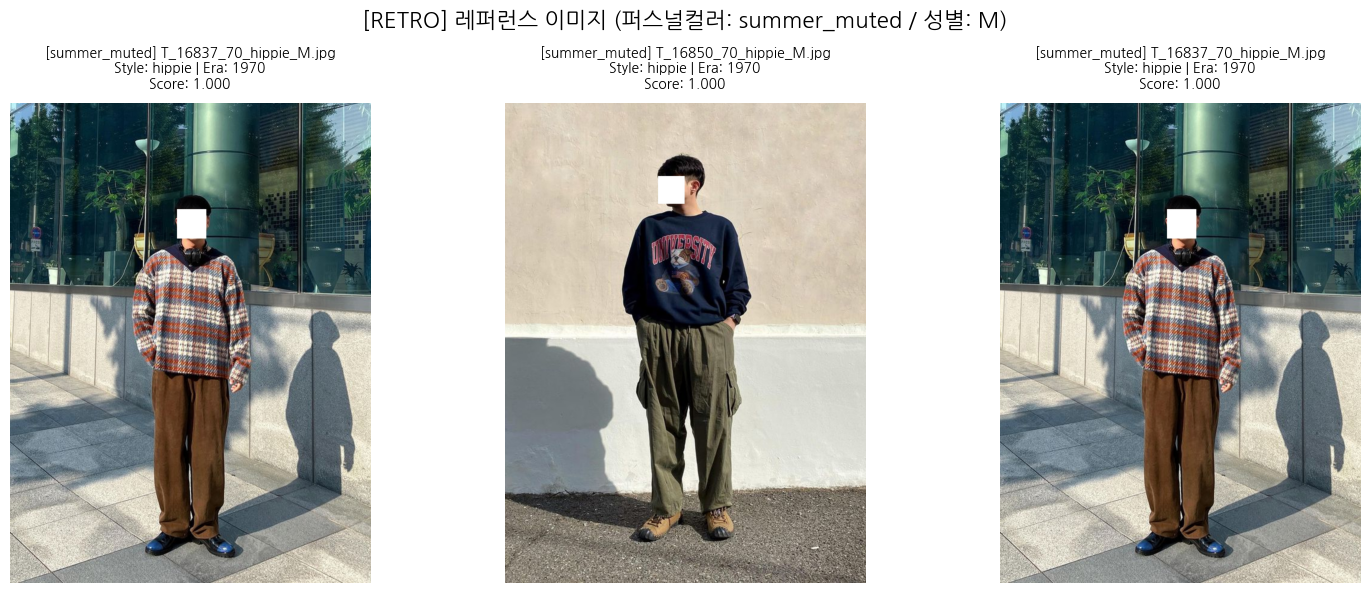



🌟 [테스트 케이스 2 실행 결과] 🌟
🛍️ [STEP 1] 무신사 / 지그재그 딥링크 연동용 메타데이터 출력
▶ 검색 키워드(스타일)     : SOPHISTICATED
▶ 검색 키워드(퍼스널컬러) : spring_bright
▶ 검색 키워드(핏)         : tight_or_normal

💡 향후 이 키워드들을 조합하여 쇼핑몰 검색 URL(딥링크)을 자동 생성할 수 있습니다.
   (예시: https://www.musinsa.com/search/musinsa/integration?q=SOPHISTICATED+spring_bright)

📸 [STEP 2] 자체 데이터셋 기반 스타일 레퍼런스 이미지


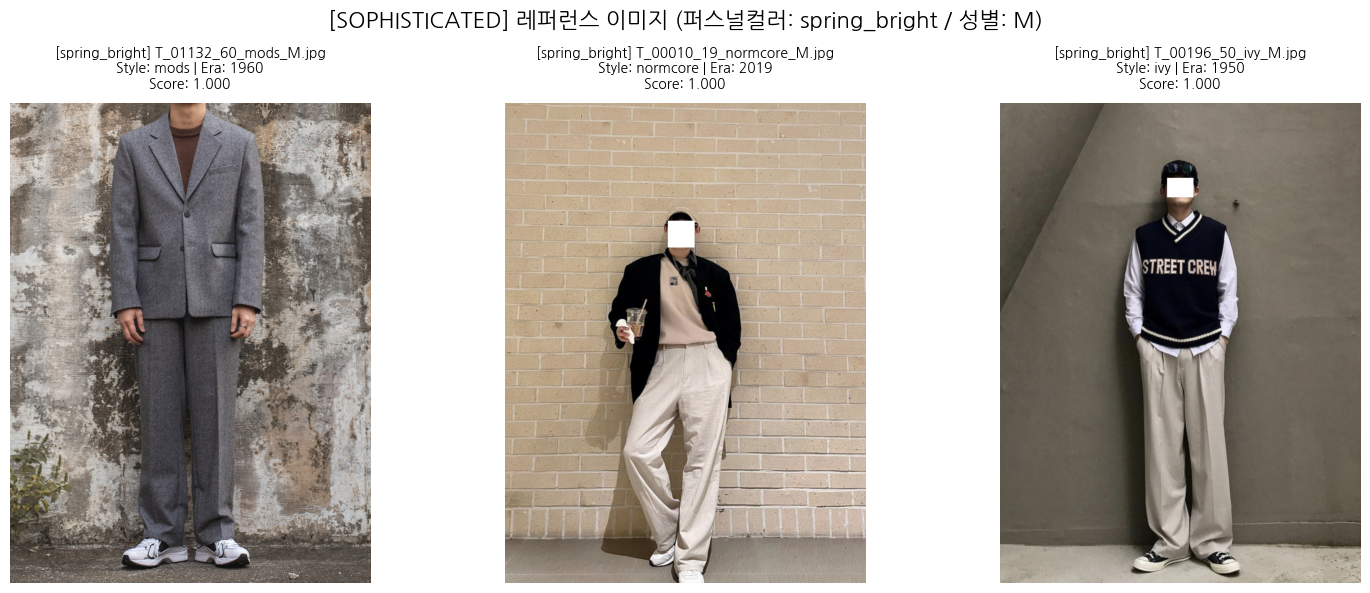

In [72]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def simulate_service_output(backend_result, image_results, base_search_path, df_images):
    primary_style = backend_result.get('primary_style', 'Unknown').upper()
    personal_color = backend_result.get('personal_color', 'Unknown')
    rec_fit = backend_result.get('recommended_fit', 'Unknown')

    print("="*60)
    print("🛍️ [STEP 1] 무신사 / 지그재그 딥링크 연동용 메타데이터 출력")
    print("="*60)
    print(f"▶ 검색 키워드(스타일)     : {primary_style}")
    print(f"▶ 검색 키워드(퍼스널컬러) : {personal_color}")
    print(f"▶ 검색 키워드(핏)         : {rec_fit}")
    print("\n💡 향후 이 키워드들을 조합하여 쇼핑몰 검색 URL(딥링크)을 자동 생성할 수 있습니다.")
    print(f"   (예시: https://www.musinsa.com/search/musinsa/integration?q={primary_style}+{personal_color})")

    print("\n" + "="*60)
    print("📸 [STEP 2] 자체 데이터셋 기반 스타일 레퍼런스 이미지")
    print("="*60)

    if not image_results:
        print("⚠️ 조건에 맞는 추천 이미지가 없습니다.\n")
        return

    # 이미지 시각화
    num_images = len(image_results)
    fig, axes = plt.subplots(1, num_images, figsize=(15, 6))
    if num_images == 1:
        axes = [axes]

    fig.suptitle(f"[{primary_style}] 레퍼런스 이미지 (퍼스널컬러: {personal_color} / 성별: {backend_result.get('gender')})",
                 fontsize=16, fontweight='bold', fontproperties=fontprop)

    for ax, res in zip(axes, image_results):
        img_name = res['imgName']
        img_path = find_image_path(img_name, base_search_path)

        # 데이터프레임에서 시대(era) 정보 추가로 가져오기
        era_info = df_images[df_images['imgName'] == img_name]['item.era'].values
        era_desc = era_info[0] if len(era_info) > 0 else 'Unknown'

        if img_path:
            img = mpimg.imread(img_path)
            ax.imshow(img)
            ax.axis('off')

            # 하단 설명 텍스트
            desc_text = f"[{personal_color}] {img_name}\nStyle: {res['style']} | Era: {era_desc}\nScore: {res['score']:.3f}"
            ax.set_title(desc_text, fontsize=11, fontproperties=fontprop, pad=10)
        else:
            ax.text(0.5, 0.5, 'Image Not Found', ha='center', va='center', fontsize=12, color='red', fontproperties=fontprop)
            ax.axis('off')

    plt.tight_layout()
    plt.show()
    print("\n")

# --- 실행 ---
print("🌟 [테스트 케이스 1 실행 결과] 🌟")
# 테스트 케이스 1(남성, summer_muted, retro)의 분석 결과 명시적 생성 및 매핑
engine_1 = RecommendationEngine(test_input_1)
backend_result_1 = engine_1.generate_recommendation()
mapped_image_results_1 = recommend_mapped_images(backend_result_1, df_with_images)

# 시각화 실행
simulate_service_output(backend_result_1, mapped_image_results_1, base_search_path, df_with_images)

print("🌟 [테스트 케이스 2 실행 결과] 🌟")
# 테스트 케이스 2(남성, inferred, sophisticated)의 분석 결과 명시적 생성 및 매핑
engine_2 = RecommendationEngine(test_input_2)
backend_result_2 = engine_2.generate_recommendation()
mapped_image_results_2 = recommend_mapped_images(backend_result_2, df_with_images)

# 시각화 실행
simulate_service_output(backend_result_2, mapped_image_results_2, base_search_path, df_with_images)


In [65]:
# 1. 구글 드라이브에 있는 압축 파일을 드라이브 내의 'images' 폴더로 바로 해제 (이미 해제되었으므로 주석 처리)
# !unzip -n "/content/drive/MyDrive/맵시TI/=================== 맵시TI ===================/Sample.zip" -d "/content/drive/MyDrive/맵시TI/images"